In [8]:
import torch
from diffusers import StableDiffusionPipeline, DDIMScheduler
import time
from IPython.display import display

# setup
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
).to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [21]:
# fixed prompt and seed
prompt = "Mountain with lake under it"
seed = 42

# dif step counts to test
step_counts = [50, 200, 999]

results = []


Running with 50 steps


  0%|          | 0/50 [00:00<?, ?it/s]

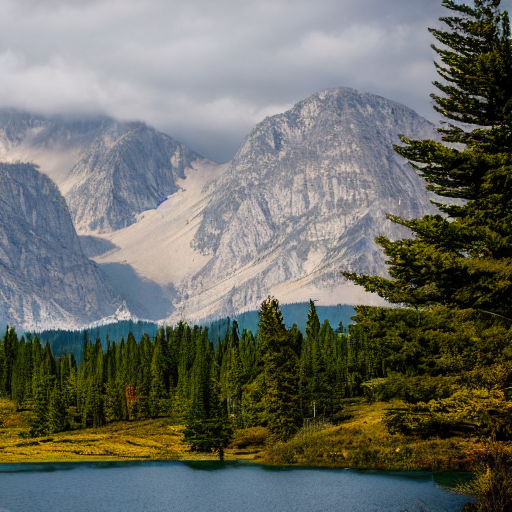

Saved: output_50_steps.png
Time taken: 2.32 seconds

Running with 200 steps


  0%|          | 0/200 [00:00<?, ?it/s]

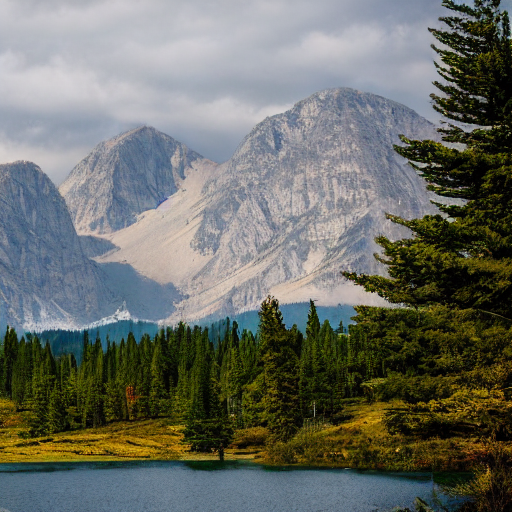

Saved: output_200_steps.png
Time taken: 8.78 seconds

Running with 999 steps


  0%|          | 0/999 [00:00<?, ?it/s]

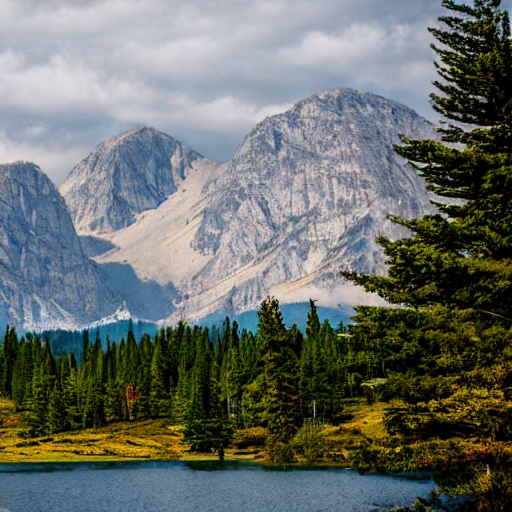

Saved: output_999_steps.png
Time taken: 43.15 seconds


In [22]:
# running experiment
for steps in step_counts:
    print(f"\nRunning with {steps} steps")

    # reinitialize generator with fixed seed
    generator = torch.Generator(device="cuda").manual_seed(seed)

    # start timing generation process
    start_time = time.time()

    # generate image using stable diffusion
    image = pipe(
        prompt=prompt,
        num_inference_steps=steps,
        generator=generator
    ).images[0]

    # end timing
    end_time = time.time()
    runtime = end_time - start_time

    # save image
    filename = f"output_{steps}_steps.png"
    image.save(filename)

    display(image)


    print(f"Saved: {filename}")
    print(f"Time taken: {runtime:.2f} seconds")

    results.append((steps, runtime))

In [23]:
# results
print("Summary")
for steps, runtime in results:
    print(f"Steps: {steps}, Time: {runtime:.2f}s")

Summary
Steps: 50, Time: 2.32s
Steps: 200, Time: 8.78s
Steps: 999, Time: 43.15s
